# SBI FOR NEUTRINO PARAMTER TUNING

In [1]:
import torch
import torch.nn as nn

import csv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import seaborn as sns
from tqdm import tqdm

from scipy.stats import norm
from sbi.analysis import sbc_rank_plot
from sbi.diagnostics import  run_sbc, run_tarp
from matplotlib import rcParams


from sbi.neural_nets import posterior_nn
from sbi.analysis import pairplot
from sbi.inference import NPE
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
seed= 555 #55, 33
np.random.seed(seed); 
torch.manual_seed(seed)
MA = 0.961242 


## Utils

In [2]:
num_posterior_samples = 100
num_sbc_samples = 1000
parameter_labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$", r"$\theta_4$"]

def plot_pretty(dpi=200, fontsize=12):
    plt.rc("savefig", dpi=dpi)       
    plt.rc('text', usetex=False)     
    plt.rc('font', size=fontsize)    
    plt.rc('xtick', direction='in')  
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=10)
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=10)
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [0.5, 1.1]) 
    return

plot_pretty()

In [3]:
def merge_txt_files(file1_path, file2_path, output_path):
    try:
        with open(file1_path, 'r') as file1, open(file2_path, 'r') as file2:
            content1 = file1.read()
            content2 = file2.read()

        with open(output_path, 'w') as output_file:
            output_file.write(content1)
            output_file.write("\n") 
            output_file.write(content2)

        print(f"Files merged successfully into {output_path}")

    except Exception as e:
        print(f"An error occurred: {e}")

# merge_txt_files("merged_output1.txt", "extra_training_data2.txt", 'merged_output.txt')

### Setting Priors

In [4]:
# Setting Priors

X1_range = (0,1)
X2_range = (0,1)
X3_range = (0,1)
X4_range = (0,1)

low = torch.tensor([min(X1_range), min(X2_range), min(X3_range), min(X4_range)])
high = torch.tensor([max(X1_range), max(X2_range), max(X3_range), max(X4_range)])
prior = BoxUniform(low=low, high=high)

sample = prior.sample((2,))
print(sample)


tensor([[0.7655, 0.4534, 0.2509, 0.1968],
        [0.7848, 0.0297, 0.7133, 0.8326]])


In [5]:
# Check prior, return PyTorch prior.
prior, num_parameters, prior_returns_numpy = process_prior(prior)

#### Load data and devide between parameter (\theta) and x (histograms 58 bins)

In [6]:
file='merged_output.txt'
with open(file, mode="r") as file:
    param_t2k = list(csv.reader(file))
data = []
for i, row in enumerate(param_t2k):
    if not row:               # skip empty lists
        continue
    numbers_t2k = re.findall(r'[-+]?(?:\d*\.\d+e[+-]?\d+|\d+\.\d+|\d+)', param_t2k[i][0])
    numbers_array_t2k = [float(num) for num in numbers_t2k]
    if len(numbers_array_t2k) == 62:
        data.append(numbers_array_t2k)
x = [i[4:] for i in data]
theta = [i[:4] for i in data]
print("length dataset = ", len(data) )

print("################### thetas before maping ##########################")
theta1 = [theta[i][0] for i in range(len(theta))]
theta2 = [theta[i][1] for i in range(len(theta))]
theta3 = [theta[i][2] for i in range(len(theta))]
theta4 = [theta[i][3] for i in range(len(theta))]
print("max", max(theta1), max(theta2), max(theta3), max(theta4))
print("min", min(theta1), min(theta2), min(theta3), min(theta4))
print("####################################################################")

theta = torch.tensor(theta, dtype=torch.float32)
theta_or = theta
theta_min = theta.min(dim=0).values
theta_max = theta.max(dim=0).values
# Normalize theta between [0,1]
theta = (theta - theta_min) / (theta_max - theta_min)

print("################### thetas after maping ##########################")
print("max",  theta[:,0].max(), theta[:,1].max(), theta[:,2].max(), theta[:,3].max())
print("min", theta[:,0].min(), theta[:,1].min(), theta[:,2].min(), theta[:,3].min())
print("####################################################################")


theta = torch.tensor(theta[2000:])
theta_test = torch.tensor(theta[:2000])
x = torch.tensor(x[2000:])
x_test = torch.tensor(x[:2000])


length dataset =  171747
################### thetas before maping ##########################
max 14.9999 3.99997 0.999996 0.999985
min -14.9996 -1.99997 2.47359e-06 -0.499995
####################################################################
################### thetas after maping ##########################
max tensor(1.) tensor(1.) tensor(1.) tensor(1.)
min tensor(0.) tensor(0.) tensor(0.) tensor(0.)
####################################################################


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/318363507.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta[2000:])
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/318363507.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_test = torch.tensor(theta[:2000])
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/318363507.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test = torch.tensor(x[:2000])


In [7]:
print("theta.shape", theta.shape)
print("x.shape", x.shape)
print("theta test.shape", theta_test.shape)
print("x test.shape", x_test.shape)

theta.shape torch.Size([169747, 4])
x.shape torch.Size([169747, 58])
theta test.shape torch.Size([2000, 4])
x test.shape torch.Size([2000, 58])


In [8]:
# Custom embedding network for x (58D → nD) n < 58
class EmbeddingNet(nn.Module):
    def __init__(self, input_dim=58, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 45),
            nn.ReLU(),
            nn.Linear(45, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim),
        )

    def forward(self, x):
        return self.net(x)


## Training

In [9]:
embedding_net = EmbeddingNet(input_dim=58, output_dim=20)

posterior_nn = posterior_nn(model="maf", embedding_net=embedding_net, hidden_features=55, num_transforms=3) 

mask = x.sum(dim=1) < 1e-30  # remove outliers
theta_sub = theta[mask]#[:N]
x_sub = x[mask]#[:N]
x_t = x_sub / x_sub.max() #We are normalizing the histogram values between [0-1] as well because v small numbers
print(x_t)


print(len(x_t))

inference = NPE(prior=prior, density_estimator=posterior_nn)
density_estimator = inference.append_simulations(theta_sub, x_t).train(
    training_batch_size=256*2,     
    stop_after_epochs=50,
    learning_rate=1e-2, 
    validation_fraction=0.1
)



tensor([[0.1029, 0.0905, 0.1363,  ..., 0.2036, 0.2272, 0.2042],
        [0.1219, 0.1818, 0.0917,  ..., 0.1375, 0.1554, 0.1593],
        [0.1553, 0.2150, 0.1373,  ..., 0.1970, 0.2279, 0.2265],
        ...,
        [0.1543, 0.2111, 0.1305,  ..., 0.1995, 0.2176, 0.2117],
        [0.1032, 0.1461, 0.0844,  ..., 0.1213, 0.1412, 0.1431],
        [0.0817, 0.0854, 0.0887,  ..., 0.1577, 0.1568, 0.1384]])
169747
 Neural network successfully converged after 277 epochs.

In [11]:
posterior = inference.build_posterior(density_estimator)

print(posterior) # prints how the posterior was trained

Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


In [12]:
mask = x_test.sum(dim=1) < 1e-30  # only keep x with some signal
theta_sub_test = theta_test[mask]
x_sub_test = x_test[mask]
x_t_t = x_sub_test / x_sub.max() #/ x_sub_test.max()
log_prob = posterior.log_prob(theta_test[0], x=x_t_t[0])
print(f"log p(θ | x): {log_prob.item():.3f}")

log p(θ | x): 15.681


#### Posterior fits for single test event

  0%|          | 0/100000 [00:00<?, ?it/s]

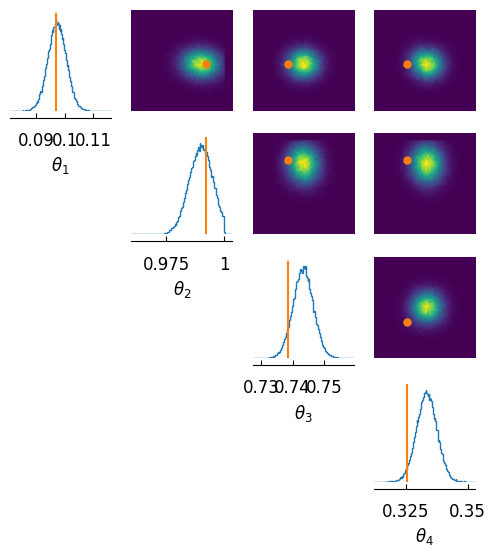

In [13]:
# Posterior fits for test event i
i=0
samples = posterior.sample((100000,), x=x_t_t[i])
pairplot(samples,
         points= theta_sub_test[i].reshape(1,4),
         figsize=(6, 6),
         labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$", r"$\theta_4$"]);

#### Statistics for Analysis

In [14]:
import gc

x_observed = torch.tensor(x_t_t, dtype=torch.float32)

def make_summary_statistic_array(x_observed, posterior, test_number = 1000):

  SBI_median_arr = []
  SBI_max_like_arr = []
  SBI_percentile68u_arr = []
  SBI_percentile68l_arr = []
  SBI_percentile95u_arr = []
  SBI_percentile95l_arr = []
  SBI_sample_array = []
  SBI_logp_array = []
  SBI_map_array = []

  for k in range(1):
    # This iterates over multiple SBI networks. If you only have one, len(posterior) should be 1.
    median_arr = []
    max_like_arr = []
    percentile68u_arr = []
    percentile68l_arr = []
    percentile95u_arr = []
    percentile95l_arr = []
    sample_array = []
    logp_array = []
    map_array = []
    for j in range(test_number):
      print(j)
      # This iterates over the number of images in the test set. If you only have one, test_number should be 1.
      median = []
      max_like = []
      percentile68u = []
      percentile68l = []
      percentile95u = []
      percentile95l = []
      samples = posterior.set_default_x(x_observed[j]).sample((1000,))
      # map = posterior[k].map(x=x_observed[j])
      # map_array.append(map.cpu().numpy())
      sample_array.append(samples.cpu())
      logp = posterior.log_prob(samples)
      logp_array.append(logp.cpu())
      argmaxlogp = torch.argmax(posterior.log_prob(samples))
      for i in range(len(samples[0])):
        # This iterates over the number of parameters per image.
        max_like.append(float(samples.cpu()[argmaxlogp][i]))
        median.append(np.median(samples.cpu()[:,i]))
        percentile68l.append(np.percentile(samples.cpu()[:,i],16))
        percentile68u.append(np.percentile(samples.cpu()[:,i],84))
        percentile95l.append(np.percentile(samples.cpu()[:,i],2.5))
        percentile95u.append(np.percentile(samples.cpu()[:,i],97.5))
      median_arr.append(median)
      max_like_arr.append(max_like)
      percentile68l_arr.append(percentile68l)
      percentile68u_arr.append(percentile68u)
      percentile95l_arr.append(percentile95l)
      percentile95u_arr.append(percentile95u)
    SBI_median_arr.append(median_arr)
    SBI_max_like_arr.append(max_like_arr)
    SBI_percentile68u_arr.append(percentile68u_arr)
    SBI_percentile68l_arr.append(percentile68l_arr)
    SBI_percentile95u_arr.append(percentile95u_arr)
    SBI_percentile95l_arr.append(percentile95l_arr)
    SBI_sample_array.append(sample_array)
    SBI_logp_array.append(logp_array)
    # SBI_map_array.append(map_array)

  SBI_median_arr = np.array(SBI_median_arr)
  SBI_max_like_arr = np.array(SBI_max_like_arr)
  SBI_percentile68u_arr = np.array(SBI_percentile68u_arr)
  SBI_percentile68l_arr = np.array(SBI_percentile68l_arr)
  SBI_percentile95u_arr = np.array(SBI_percentile95u_arr)
  SBI_percentile95l_arr = np.array(SBI_percentile95l_arr)
  # SBI_sample_array = np.array(SBI_sample_array)
  SBI_sample_array = SBI_sample_array
  SBI_logp_array = SBI_logp_array
  # SBI_map_array = np.array(SBI_map_array)

  return SBI_sample_array, SBI_logp_array, SBI_map_array, SBI_median_arr, SBI_max_like_arr, SBI_percentile68u_arr, SBI_percentile68l_arr, SBI_percentile95u_arr, SBI_percentile95l_arr

array_dump = make_summary_statistic_array(x_observed, posterior, 1000)

import pickle
file_name = f"4_parameter_npe_summary.pkl"
open_file = open(file_name, "wb")
pickle.dump(array_dump, open_file)
open_file.close()

0


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/2416906237.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_observed = torch.tensor(x_t_t, dtype=torch.float32)


  0%|          | 0/1000 [00:00<?, ?it/s]

1


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

998


  0%|          | 0/1000 [00:00<?, ?it/s]

999


  0%|          | 0/1000 [00:00<?, ?it/s]

In [15]:
SBI_sample_array, SBI_logp_array, SBI_map_array, SBI_best_fit_arr, SBI_max_like_arr, SBI_percentile68u_arr, SBI_percentile68l_arr, SBI_percentile95u_arr, SBI_percentile95l_arr = array_dump
test_number = 1000

prior_low = [min(X1_range), min(X2_range), min(X3_range), min(X4_range)]
prior_high = [max(X1_range), max(X2_range), max(X3_range), max(X4_range)]

limits = np.array([prior_low, prior_high]).T

theta_1 = [theta_sub[:test_number][i][0] for i in range(test_number)]
theta_2 = [theta_sub[:test_number][i][1] for i in range(test_number)]
theta_3 = [theta_sub[:test_number][i][2] for i in range(test_number)]
theta_4 = [theta_sub[:test_number][i][3] for i in range(test_number)]

theta_1, theta_2, theta_3, theta_4 = np.array(theta_1), np.array(theta_2), np.array(theta_3), np.array(theta_4)

print(theta_1.min(), theta_1.max())
print(theta_2.min(), theta_2.max())
print(theta_3.min(), theta_3.max())
print(theta_4.min(), theta_4.max())

true_parameter = np.array([theta_1, theta_2, theta_3, theta_4])

best_fit_t_diff = SBI_best_fit_arr[0,:test_number,:]-true_parameter.T
max_cut = (SBI_max_like_arr[0,:test_number,:]-true_parameter.T) / true_parameter.T # percentage
max_cut_ext = np.append(max_cut, SBI_max_like_arr[0,:test_number,:],axis=1)

error = SBI_percentile68u_arr[0,:test_number,:] - SBI_percentile68l_arr[0,:test_number,:]

max_cut_norm = max_cut/error
max_cut_ext_norm = np.append(max_cut_norm, SBI_max_like_arr[0,:test_number,:], axis=1)


from getdist import plots, MCSamples
from getdist.styles.tab10 import style_name
plots.set_active_style(style_name)

SBIsamples_plot = MCSamples(
    samples=max_cut_ext, 
    names=[
        r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4',
        r'\theta_1_t', r'\theta_2_t', r'\theta_3_t', r'\theta_4_t'
    ],
    labels=[
        r'\Delta \theta_1', r'\Delta \theta_2', r'\Delta \theta_3', r'\Delta \theta_4',
        r'\Delta \theta_1_t', r'\Delta \theta_2_t', r'\Delta \theta_3_t', r'\Delta \theta_4_t'
    ],
    settings={'fine_bins': 2048, 'fine_bins_2D': 2048, 
              'smooth_scale_1D': 0.05, 'smooth_scale_2D': 0.05}
)


0.00038001375 0.99979335
0.0019050034 0.99968004
4.5304503e-05 0.99948597
0.00073133886 0.99849135
Removed no burn in


## Residuals 

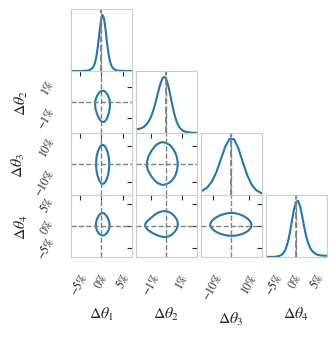

In [62]:
# Percentage 
from matplotlib.ticker import PercentFormatter, MaxNLocator
sns.set_style("whitegrid")
a=0.07
# a=0.02 # two contours
# a=0.01 # single contour
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "font.size": 10,
    "mathtext.fontset": "stix",
    "text.usetex": False,
    "axes.grid": False,   # <- this disables grids
})

g = plots.get_subplot_plotter(width_inch=3.5)
# g.settings.axes_fontsize=12
g.settings.axis_tick_x_rotation=60
g.settings.axis_tick_y_rotation=60
g.settings.scaling_factor = 1
g.settings.linewidth=2
g.settings.num_plot_contours = 1
g.triangle_plot(
    [SBIsamples_plot],
    [r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'],
    colors=['tab:blue'],
    line_args=[{'color': 'tab:blue', 'lw': 2}],
    contour_levels=[0.68], 
    contour_lws=[1.5],
    markers={
        r'\theta_1': 0, r'\theta_2': 0, r'\theta_3': 0, r'\theta_4': 0
    },
    param_limits = {r'\theta_1':[-a,a],r'\theta_2':[-a+0.05,a-0.05],r'\theta_3':[-a-0.1,a+0.1],r'\theta_4':[-a,a]},
    marker_args={'lw': 1},
    title_limit=0
)
for i in range(len(g.subplots[0,:])):
  g.subplots[i,i].axvline(color='gray', ls='--', lw=1.3)
  g.subplots[i,i].xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
  for j in range(i):
        g.subplots[i,j].xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
        g.subplots[i,j].yaxis.set_major_formatter(PercentFormatter(1, decimals=0))

plt.grid(False)
plt.savefig('4param_corner_all.pdf',format='pdf')

## Error analysis test set

In [17]:
# Reminder of which x and thetas are we using as test set
mask = x_test.sum(dim=1) < 1e-30  
theta_sub_test = theta_test[mask]
x_sub_test = x_test[mask]
x_t_t = x_sub_test / x_sub.max() 

y_pred =[torch.mean(posterior.sample((100,), x=x_t_t[i].detach().numpy()), axis=0) for i in range(len(x_t_t))]
y_truth = theta_sub_test[:1000].detach().numpy()

SBI_sample_array_test, SBI_logp_array_test, SBI_map_array_test, SBI_best_fit_arr_test, \
SBI_max_like_arr_test, SBI_percentile68u_arr_test, SBI_percentile68l_arr_test, \
SBI_percentile95u_arr_test, SBI_percentile95l_arr_test = make_summary_statistic_array(x_t_t, posterior, 1000)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

998


  0%|          | 0/1000 [00:00<?, ?it/s]

999


  0%|          | 0/1000 [00:00<?, ?it/s]

In [18]:
SBI_error_1sigma_test = SBI_percentile68u_arr_test - SBI_percentile68l_arr_test
mean_sigma_1_errors_test = SBI_error_1sigma_test.mean(axis=1)
print(mean_sigma_1_errors_test.squeeze())

[0.00527826 0.0065321  0.0208223  0.00831178]


### Physical Units

##### In orther to compare our results with other analysis like MicroBoonE we need to convert from GENIE units to physical units

In [19]:
MA = 0.961242  # GeV

theta_max = np.array([theta_or[:,0].max(), theta_or[:,1].max(), theta_or[:,2].max(), theta_or[:,3].max()])
theta_min = np.array([theta_or[:,0].min(), theta_or[:,1].min(), theta_or[:,2].min(), theta_or[:,3].min()])
print(theta_max)
print(theta_min)

y_normalized = SBI_best_fit_arr_test.mean(axis=1).squeeze()
yerr_normalized = mean_sigma_1_errors_test.squeeze()

# Reverse normalization to original range
theta_original = y_normalized * (theta_max - theta_min) + theta_min
theta_errors = yerr_normalized * (theta_max - theta_min)

# Convert to physics units
y_physical = np.array([
    MA * (1 + 0.03 * theta_original[0]),        
    1 + 0.5 * theta_original[1],                
    theta_original[2],                          
    1 - theta_original[3]                       
])

# Error propagation
yerr_physical = np.array([
    MA * 0.03 * theta_errors[0],                
    0.5 * theta_errors[1],                      
    theta_errors[2],                            
    theta_errors[3]                             
])



[14.9999    3.99997   0.999996  0.999985]
[-1.49996e+01 -1.99997e+00  2.47359e-06 -4.99995e-01]


#### True Vs Pred

(100, 4)


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/822453220.py:83: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


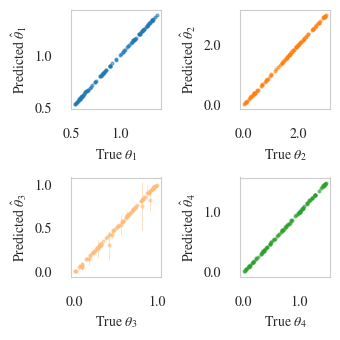

In [21]:
CB_DATA  = "#1B9E77"   
CB_BLACK  = "#333333" 
import matplotlib.ticker as ticker
sns.set_style("whitegrid")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "font.size": 10,
    "mathtext.fontset": "stix",
    "text.usetex": False,
})

y_truth_ = np.array(y_truth[:100] * (theta_max - theta_min) + theta_min)
y_truth_phy = y_truth_.copy()
y_truth_phy[:, 0] = MA * (1 + 0.03 * y_truth_[:, 0])
y_truth_phy[:, 1] = 1 + 0.5 * y_truth_[:, 1]
y_truth_phy[:, 2] = y_truth_[:, 2]
y_truth_phy[:, 3] = 1 - y_truth_[:, 3]

y_pred_ = np.array(y_pred[:100] * (theta_max - theta_min) + theta_min)
y_pred_phy = y_pred_.copy()
y_pred_phy[:, 0] = MA * (1 + 0.03 * y_pred_[:, 0])
y_pred_phy[:, 1] = 1 + 0.5 * y_pred_[:, 1]
y_pred_phy[:, 2] = y_pred_[:, 2]
y_pred_phy[:, 3] = 1 - y_pred_[:, 3]


SBI_error_1sigma_test_ = SBI_error_1sigma_test.squeeze()[:100, :]

SBI_error_1sigma_ = np.array(SBI_error_1sigma_test_ * (theta_max - theta_min))
SBI_error_1sigma_phy = SBI_error_1sigma_.copy()
SBI_error_1sigma_phy[:, 0] = MA * 0.03 * SBI_error_1sigma_[:, 0]
SBI_error_1sigma_phy[:, 1] = 0.5 * SBI_error_1sigma_[:, 1]
SBI_error_1sigma_phy[:, 2] = SBI_error_1sigma_[:, 2]
SBI_error_1sigma_phy[:, 3] = SBI_error_1sigma_[:, 3]

print(SBI_error_1sigma_phy.shape)

n_params = y_truth_.shape[1]
theta_labels = [r'$\theta_1$', r'$\theta_2$', r'$\theta_3$', r'$\theta_4$']

ncols = 2
nrows = int(np.ceil(n_params / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3.5,3.5))
axes = axes.flatten()

# These are the "Tableau 20" colors as RGB.
tableau20 = [(31, 119, 180), (255, 127, 14), (255, 187, 120),
             (44, 160, 44), (152, 223, 138), (214, 39, 40), (255, 152, 150),
             (148, 103, 189), (140, 86, 75),
             (227, 119, 194), (23, 190, 207), (158, 218, 229)]
    
for i in range(n_params):
    ax = axes[i]

    r, g, b = tableau20[i]
    tableau20[i] = (r / 255., g / 255., b / 255.)

    ax.errorbar(
        y_truth_phy[:, i],
        y_pred_phy[:, i],
        yerr=np.abs(SBI_error_1sigma_phy[:, i]),
        fmt='o',
        markersize=2,
        color=tableau20[i],
        elinewidth=0.6,
        alpha=0.5,
    )

    ax.set_xlabel(fr"True $\theta_{{{i+1}}}$")
    ax.set_ylabel(fr"Predicted $\hat{{\theta}}_{{{i+1}}}$")
    ax.grid(False)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.1f}'))
    ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.1f}'))
# remove extra axes
for j in range(n_params, nrows*ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("True_vs_Predicted.pdf", format="pdf", bbox_inches='tight')
fig.show()


### Pulls

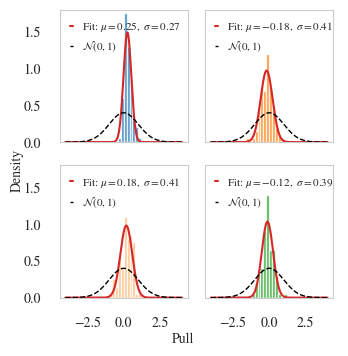

In [22]:
CB_BLUE   = "#0072B2"
CB_ORANGE = "#E69F00"
CB_BLACK  = "#000000"
CB_GRAY   = "#4D4D4D"
sns.set_style("whitegrid")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "font.size": 10,
    "mathtext.fontset": "stix",
    "text.usetex": False,
})

# pulls shape: (N_events, N_params)
pulls = (y_pred_phy[:100] - y_truth_phy[:100]) / SBI_error_1sigma_phy#.squeeze()[:100, :]#mean_sigma_1_errors_test
n_params = pulls.shape[1]

theta_labels = [r'$\theta_1$', r'$\theta_2$', r'$\theta_3$', r'$\theta_4$']

# Grid
ncols = 2
nrows = int(np.ceil(n_params / ncols))

fig, axes = plt.subplots( nrows, ncols, figsize=(3.5, 3.5), sharex=True, sharey=True)
axes = np.array(axes).flatten()

# Fixed bin edges for visual consistency
bin_edges = np.linspace(-4, 4, 41)

tableau20 = [(31, 119, 180), (255, 127, 14), (255, 187, 120),
             (44, 160, 44), (152, 223, 138), (214, 39, 40), (255, 152, 150),
             (148, 103, 189), (140, 86, 75),
             (227, 119, 194), (23, 190, 207), (158, 218, 229)]

for i in range(n_params):
    ax = axes[i]
    r, g, b = tableau20[i]
    tableau20[i] = (r / 255., g / 255., b / 255.)

    # Histogram
    ax.hist(pulls[:, i],bins=bin_edges, density=True, alpha=0.8, color=tableau20[i])#, label="Pulls")

    # Gaussian fit
    mu, sigma = norm.fit(pulls[:, i])
    x = np.linspace(-4, 4, 400)

    ax.plot(
        x,
        norm.pdf(x, mu, sigma),
        color=(214/ 255., 39/ 255., 40/ 255.),
        # alpha=0.8,
        # linestyle="--",
        lw=1.5,
        label=fr'Fit: $\mu={mu:.2f},\ \sigma={sigma:.2f}$'
    )

    # Standard normal
    ax.plot(
        x,
        norm.pdf(x),
        color=CB_BLACK,
        lw=1,
        linestyle="--",
        label=r'$\mathcal{N}(0,1)$'
    )

    ax.legend(fontsize=8, loc="upper left", frameon=False, handlelength=0.3)
    ax.grid(False)
    ax.set_ylim([0, 1.8])
# Remove unused axes
for j in range(n_params, nrows * ncols):
    fig.delaxes(axes[j])
fig.text(0.5, 0.005, 'Pull', ha='center')      # x-axis
fig.text(0.005, 0.5, 'Density', va='center', rotation='vertical')
plt.tight_layout()
plt.savefig("Pulls.pdf", format="pdf", bbox_inches="tight")
plt.show()


## Calibration

/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/3013589345.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  samples = np.array(SBI_sample_array[0][index])
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/3013589345.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  logp = np.array(SBI_logp_array[0][index])


Removed no burn in


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/3013589345.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  samples = np.array(SBI_sample_array[0][index])
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/3013589345.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  logp = np.array(SBI_logp_array[0][index])


Removed no burn in


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/3013589345.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  samples = np.array(SBI_sample_array[0][index])
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/3013589345.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  logp = np.array(SBI_logp_array[0][index])


...

Removed no burn in


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/3013589345.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  samples = np.array(SBI_sample_array[0][index])
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/3013589345.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  logp = np.array(SBI_logp_array[0][index])


Removed no burn in


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/3013589345.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  samples = np.array(SBI_sample_array[0][index])
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/3013589345.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  logp = np.array(SBI_logp_array[0][index])


Removed no burn in


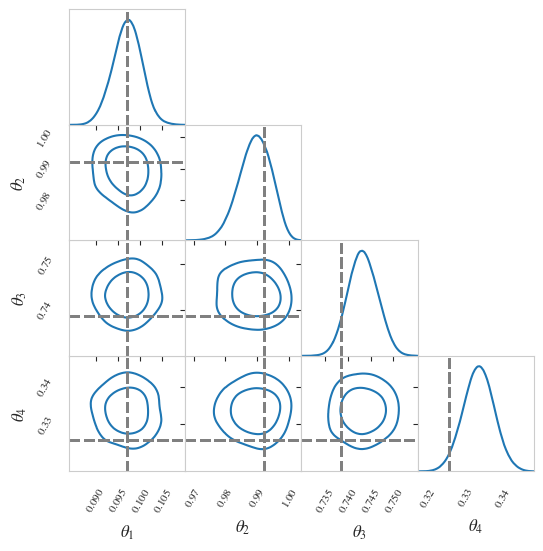

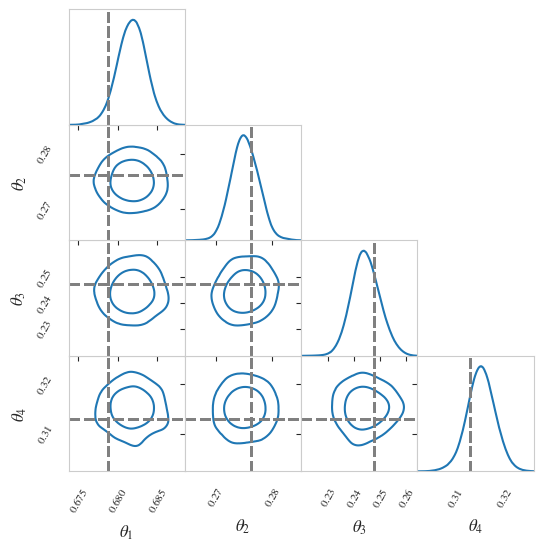

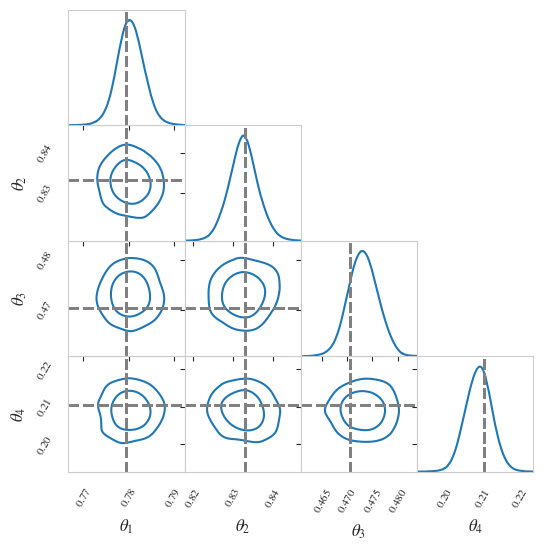

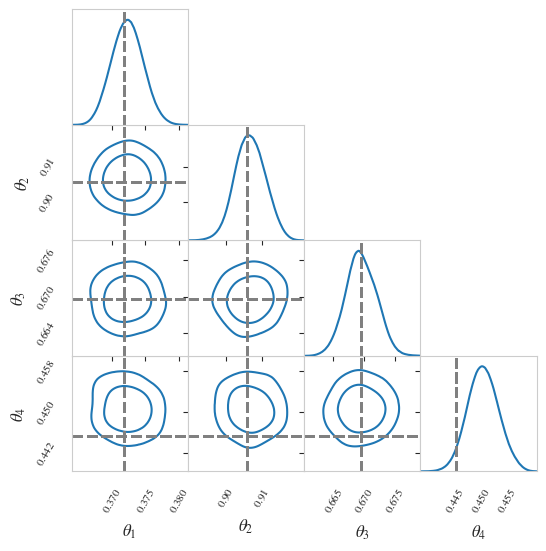

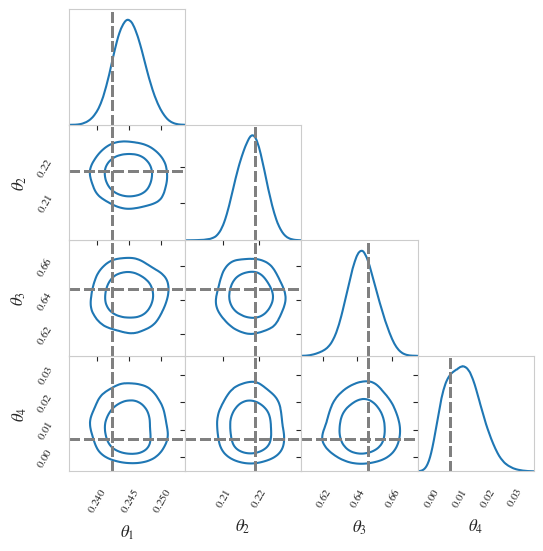

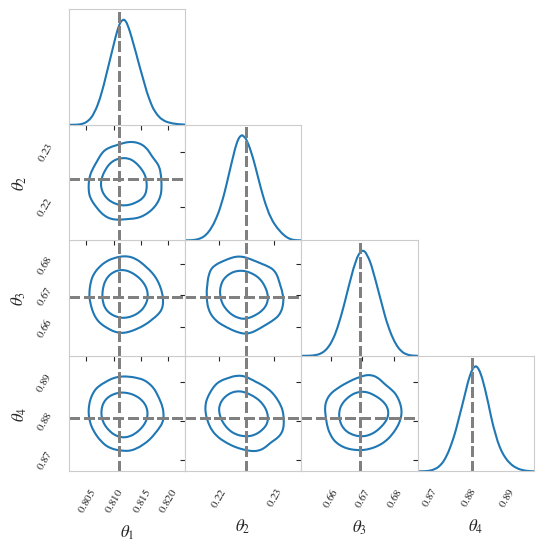

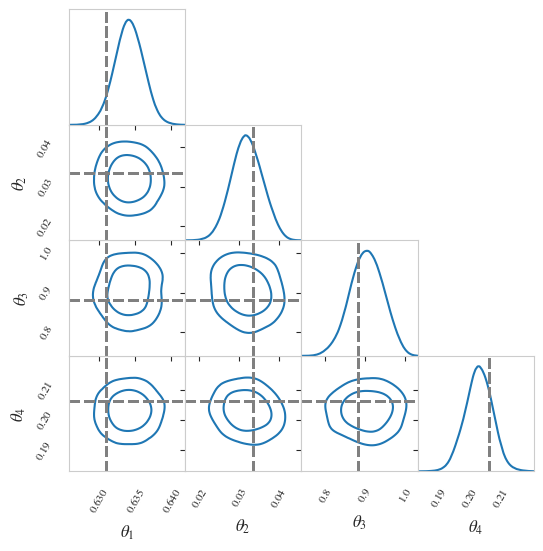

In [29]:
%matplotlib inline
plot_pretty()
rcParams.update({"text.usetex": False})
rcParams['font.family'] = 'serif'

test_number = 1000
prior_low = [min(X1_range), min(X2_range), min(X3_range), min(X4_range)]
prior_high = [max(X1_range), max(X2_range), max(X3_range), max(X4_range)]

limits = np.array([prior_low, prior_high]).T
weird_index = [[0,1,2,3,8,9,10]]
# weird_index = [[9]]

for i, index in enumerate(np.ravel(weird_index[0])):

  theta_1 = [theta_sub[:test_number][index][0] for i in range(test_number)]
  theta_2 = [theta_sub[:test_number][index][1] for i in range(test_number)]
  theta_3 = [theta_sub[:test_number][index][2] for i in range(test_number)]
  theta_4 = [theta_sub[:test_number][index][3] for i in range(test_number)]

  samples = np.array(SBI_sample_array[0][index])
  logp = np.array(SBI_logp_array[0][index])
  # map = np.array(SBI_map_array[0,index])
  best_fit_t = SBI_best_fit_arr[0,index,:]
  max_like_t = SBI_max_like_arr[0,index,:]


  SBIsingle = MCSamples(samples=np.array(samples),
                            names=[
                                r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'#,
                                # r'\theta_1_t', r'\theta_2_t', r'\theta_3_t', r'\theta_4_t'
                            ],
                            labels=[
                                r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'#,
                                # r'\Delta \theta_1_t', r'\Delta \theta_2_t', r'\Delta \theta_3_t', r'\Delta \theta_4_t'
                            ])


  g = plots.get_subplot_plotter(width_inch=6)
  g.settings.scaling_factor = 1
  g.settings.axes_fontsize=10
  g.settings.axis_tick_x_rotation=60
  g.settings.axis_tick_y_rotation=60
  g.settings.scaling_factor = 1
  g.settings.title_limit_labels = False
  g.settings.title_limit_fontsize = 10
  g.settings.axis_marker_lw = 2
  g.settings.tight_layout = False
  g.settings.constrained_layout = False
  g.triangle_plot([SBIsingle],[r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'],
                colors=['tab:blue','tab:orange'],
                contour_lws = [1.5,1.5],
                line_args=[{'color':'tab:blue'},{'color':'tab:orange'}],
                 marker_args ={'lw':2},
                  markers={r'\theta_1':theta_1,r'\theta_2':theta_2, r'\theta_3':theta_3, r'\theta_4':theta_4},
                #   param_limits = {r'\theta_1':[-0,1],r'\theta_2':[-0,1],r'\theta_3':[-0,1],r'\theta_4':[0,1]},
                  title_limit=0)
  plt.grid(False)
  plt.savefig('4param_single_image_corner_%s_%s.pdf',format='pdf')

/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/1162958321.py:27: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  samples = np.array(SBI_sample_array[0][index])
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/1162958321.py:28: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  logp = np.array(SBI_logp_array[0][index])


Removed no burn in


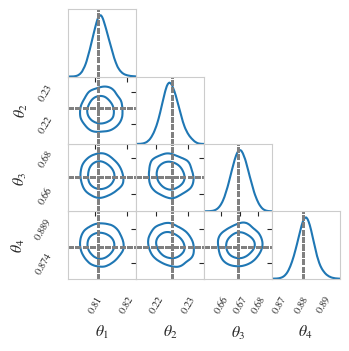

In [31]:
sns.set_style("whitegrid")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "font.size": 10,
    "mathtext.fontset": "stix",
    "text.usetex": False,
    "axes.grid": False,   # <- this disables grids
})

test_number = 1000
prior_low = [min(X1_range), min(X2_range), min(X3_range), min(X4_range)]
prior_high = [max(X1_range), max(X2_range), max(X3_range), max(X4_range)]

limits = np.array([prior_low, prior_high]).T
# weird_index = [[0,1,2,3,8,9,10]]
weird_index = [[9]]

for i, index in enumerate(np.ravel(weird_index[0])):

  theta_1 = [theta_sub[:test_number][index][0] for i in range(test_number)]
  theta_2 = [theta_sub[:test_number][index][1] for i in range(test_number)]
  theta_3 = [theta_sub[:test_number][index][2] for i in range(test_number)]
  theta_4 = [theta_sub[:test_number][index][3] for i in range(test_number)]

  samples = np.array(SBI_sample_array[0][index])
  logp = np.array(SBI_logp_array[0][index])
  # map = np.array(SBI_map_array[0,index])
  best_fit_t = SBI_best_fit_arr[0,index,:]
  max_like_t = SBI_max_like_arr[0,index,:]


  SBIsingle = MCSamples(samples=np.array(samples),
                            names=[
                                r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'#,
                                # r'\theta_1_t', r'\theta_2_t', r'\theta_3_t', r'\theta_4_t'
                            ],
                            labels=[
                                r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'#,
                                # r'\Delta \theta_1_t', r'\Delta \theta_2_t', r'\Delta \theta_3_t', r'\Delta \theta_4_t'
                            ])


  g = plots.get_subplot_plotter(width_inch=3.5)
  g.settings.scaling_factor = 1
  g.settings.axes_fontsize=10
  g.settings.axis_tick_x_rotation=60
  g.settings.axis_tick_y_rotation=60
  g.settings.scaling_factor = 1
  g.settings.title_limit_labels = False
  g.settings.title_limit_fontsize = 10
  g.settings.axis_marker_lw = 1
  g.settings.tight_layout = False
  g.settings.constrained_layout = False
  g.triangle_plot([SBIsingle],[r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'],
                colors=['tab:blue','tab:orange'],
                contour_lws = [1.5,1.5],
                line_args=[{'color':'tab:blue'},{'color':'tab:orange'}],
                 marker_args ={'lw':1},
                  markers={r'\theta_1':theta_1,r'\theta_2':theta_2, r'\theta_3':theta_3, r'\theta_4':theta_4},
                #   param_limits = {r'\theta_1':[-0,1],r'\theta_2':[-0,1],r'\theta_3':[-0,1],r'\theta_4':[0,1]},
                  title_limit=0)  
  plt.savefig('4param_single_image_corner.pdf',format='pdf', bbox_inches='tight')

### TARP

/Users/karla/venvs/py312/lib/python3.12/site-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 50 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(


Drawing 100 samples for 2000 observations:   0%|          | 0/100 [00:00<?, ?it/s]

(<Figure size 600x600 with 1 Axes>,
 <Axes: xlabel='Credibility Level $\\alpha$', ylabel='Expected Coverage Probability'>)

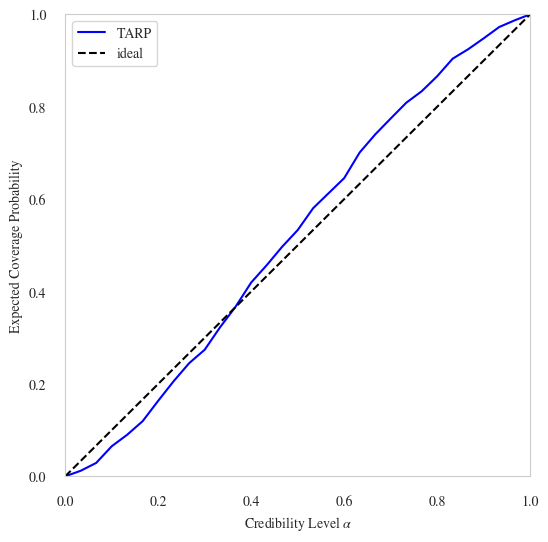

In [32]:
from sbi.analysis.plot import plot_tarp
ecp, alpha = run_tarp(
    theta_sub_test,
    x_t_t,
    posterior,
    references=None,  # will be calculated automatically.
    num_posterior_samples=100,
)
plt.rcParams['text.usetex'] = False

plot_tarp(ecp, alpha)

In [33]:
def calculate_coverage_fraction(x_observed, pos_list, truth_array, percentile_list, test_number=100, sample_number = 1000):
  count_array = []
  for i in range(test_number):
    samples = pos_list.set_default_x(x_observed[i]).sample((sample_number,),show_progress_bars=False)
    count_vector = []
    for ind, cov in enumerate(percentile_list):
      percentile_l = 50.0 - cov/2
      percentile_u = 50.0 + cov/2
      confidence_l = np.percentile(samples.cpu(),percentile_l,axis=0)
      confidence_u = np.percentile(samples.cpu(),percentile_u,axis=0)
      count = np.logical_and(confidence_u - truth_array.T[i] > 0, truth_array.T[i] - confidence_l > 0)
      count_vector.append(count)
    count_array.append(count_vector)
  count_sum_array = np.sum(count_array, axis=0)
  frac_lens_within_vol = np.array(count_sum_array)
  return np.array(frac_lens_within_vol).T/sample_number

def distance(param_vector, mean_vector, covariance):
  d = np.array(param_vector-mean_vector)
  return d.dot(covariance).dot(d.T)

def calculate_coverage_fraction_distance_2(x_observed, pos_list, truth_array, percentile_list, covariance, test_number=100, sample_number = 1000):
  count_array = []
  for i in range(test_number):
    samples = pos_list.set_default_x(x_observed[i]).sample((sample_number,),show_progress_bars=False).cpu()
    count_vector = []
    mean = np.median(samples, axis=0)
    for ind, percentile in enumerate(percentile_list):
      d = distance(samples, mean, covariance)
      d_true = distance(truth_array[:,i], mean, covariance)
      d_array = d.diagonal()
      # difference = abs(np.array(samples)-mean)
      # difference_true = abs(.T[i]-mean)
      confidence_l = np.percentile(d_array, percentile, axis=0)
      count = confidence_l - d_true > 0
      count_vector.append(count)
    count_array.append(count_vector)
  return np.sum(np.array(count_array), axis=0)/len(samples)

percentile_array = np.linspace(0,100,21)

In [34]:
theta_1 = [theta_sub[:test_number][i][0] for i in range(test_number)]
theta_2 = [theta_sub[:test_number][i][1] for i in range(test_number)]
theta_3 = [theta_sub[:test_number][i][2] for i in range(test_number)]
theta_4 = [theta_sub[:test_number][i][3] for i in range(test_number)]
true_array = np.array([theta_1, theta_2, theta_3, theta_4])
percentile_array = np.linspace(0,100,21)
frac_array = calculate_coverage_fraction(x_t_t, posterior, true_array, percentile_array, test_number)
cov = np.cov(true_array)
frac_array_combined = calculate_coverage_fraction_distance_2(x_observed, posterior, true_array, percentile_array, cov, test_number)


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/2185358082.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  d = np.array(param_vector-mean_vector)
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/2185358082.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  d = np.array(param_vector-mean_vector)


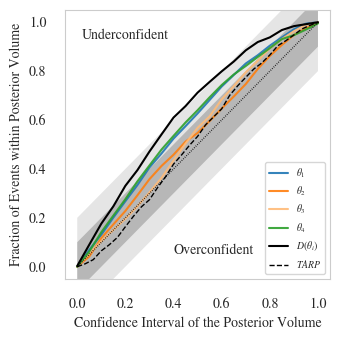

In [35]:
percentile_array = np.linspace(0,100,21)
percentile_array_norm = np.array(percentile_array)/100

from cycler import cycler
plot_rc_params = {
    'mathtext.fontset' : 'stix',
    'font.family' : 'STIXGeneral',
    'font.size' : 10,
    'mathtext.fontset' : 'cm',
    # 'axes.formatter.use_mathtext' : True
}
# These are the "Tableau 20" colors as RGB.
tableau20 = [(31, 119, 180), (255, 127, 14), (255, 187, 120),
             (44, 160, 44), (152, 223, 138), (214, 39, 40), (255, 152, 150),
             (148, 103, 189), (140, 86, 75),
             (227, 119, 194), (23, 190, 207), (158, 218, 229)]

#(174, 199, 232)

# Scale the RGB values to the [0, 1] range, which is the format matplotlib accepts.
for i in range(len(tableau20)):
    r, g, b = tableau20[i]
    tableau20[i] = (r / 255., g / 255., b / 255.)

default_cycler = (cycler(color=tableau20[:10]) + cycler(linestyle=['-','-','-','-',':',':','--','--','--','--']))

plt.rc('lines', linewidth=1.5)
plt.rc('axes', prop_cycle=default_cycler)

sns.set_style("whitegrid")
rcParams.update({"text.usetex": False})
rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(1,1,figsize=(3.5,3.5))
plt.plot(percentile_array_norm, frac_array.T, alpha = .9)
plt.plot(percentile_array_norm, frac_array_combined, c = 'k',ls='-')
plt.plot(alpha, ecp, color='black', lw=1, label='TARP', linestyle="--")
plt.plot([0,0.5,1],[0,0.5,1], 'k:', lw=1, zorder=1000)
plt.fill_between(
    x=percentile_array_norm,
    y1=percentile_array_norm-0.1,
    y2=percentile_array_norm+0.1,
    color='k',
    edgecolor="none",
    alpha=0.2,)
plt.fill_between(
    x=percentile_array_norm,
    y1=percentile_array_norm-0.2,
    y2=percentile_array_norm+0.2,
    color='k',
    edgecolor="none",
    alpha=0.1,)
plt.xlim([-0.05,1.05])
plt.ylim([-0.05,1.05])
plt.text(0.02,0.93,'Underconfident', fontsize=10, horizontalalignment='left')
plt.text(0.4,0.05,'Overconfident',fontsize =10, horizontalalignment='left')
plt.legend([r'$\theta_1$', r'$\theta_2$', r'$\theta_3$', r'$\theta_4$', r'$D(\theta_i)$', r'$TARP$'], prop={'size': 7}, ncol=1, loc=4)
plt.xlabel('Confidence Interval of the Posterior Volume')
plt.ylabel('Fraction of Events within Posterior Volume')
# plt.title(f'NPE')
plt.tight_layout()
plt.grid(False)
plt.savefig(f'4_param_npe_pos.pdf', format='pdf')

## Testing with T2K Data

In [36]:
posterior = inference.build_posterior(density_estimator, sample_with='mcmc')

/Users/karla/venvs/py312/lib/python3.12/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


In [70]:
file='my_data_hists_out.txt'
file_ub="ub_tune_hist_out.txt"

with open(file, mode="r") as file:
    param_t2k = list(csv.reader(file))
x_t2k = []
numbers_ar_t2k=[]
for i in range(0,1000): 
    numbers_t2k = re.findall(r'[-+]?(?:\d*\.\d+e[+-]?\d+|\d+\.\d+|\d+)', param_t2k[i][0])
    numbers_array_t2k = [float(num) for num in numbers_t2k]
    numbers_ar_t2k.append(numbers_array_t2k)
    if len(numbers_array_t2k) == 58:
        x_t2k.append(numbers_array_t2k)

with open(file_ub, mode="r") as file:
    param_ub = list(csv.reader(file))
x_ub = []
numbers_ar_ub=[]
for i in range(len(param_ub)): 
    numbers_ub = re.findall(r'[-+]?(?:\d*\.\d+e[+-]?\d+|\d+\.\d+|\d+)', param_ub[i][0])
    numbers_array_ub = [float(num) for num in numbers_ub]
    numbers_ar_ub.append(numbers_array_ub)
    if len(numbers_array_ub) == 58:
        x_ub.append(numbers_array_ub)

In [73]:
x_t2k = [x_t2k[i] / x_sub.max().detach().numpy() for i in range(len(x_t2k))]
x_ub = [x_ub[i] / x_sub.max().detach().numpy() for i in range(len(x_ub))]

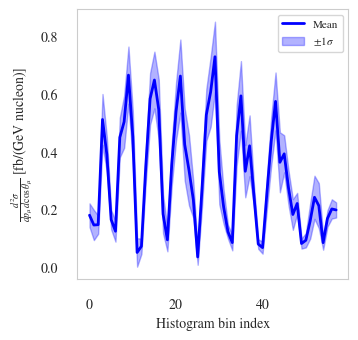

In [39]:
sns.set_style("whitegrid")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "font.size": 10,
    "mathtext.fontset": "stix",
    "text.usetex": False,
})

mean_vals = np.mean(x_t2k, axis=0)
std_vals = np.std(x_t2k, axis=0)

plt.figure(figsize=(3.5,3.5))
plt.plot(mean_vals, color="b", lw=2, label='Mean')
plt.fill_between(
    np.arange(len(mean_vals)),
    mean_vals - std_vals,
    mean_vals + std_vals,
    color="b", alpha=0.3, label=r'$\pm 1\sigma$'
)
plt.xlabel("Histogram bin index", fontsize=10)
plt.ylabel(r"$\frac{d^{2}\sigma}{dp_{\mu}\, d\cos\theta_{\mu}}\;[\mathrm{fb}/(\mathrm{GeV\ nucleon})]$")
plt.grid(False)
plt.legend(fontsize=8)
plt.savefig("Hist_variation_t2k.pdf", format="pdf", bbox_inches='tight')
plt.show()


In [40]:
array_dump_ub = make_summary_statistic_array([x_ub], posterior, 1)

SBI_sample_array_ub, SBI_logp_array_ub, SBI_map_array_ub, SBI_best_fit_arr_ub, \
SBI_max_like_arr_ub, SBI_percentile68u_arr_ub, SBI_percentile68l_arr_ub, \
SBI_percentile95u_arr_ub, SBI_percentile95l_arr_ub = array_dump_ub

SBI_error_1sigma_ub = SBI_percentile68u_arr_ub - SBI_percentile68l_arr_ub
mean_sigma_1_errors_ub = SBI_error_1sigma_ub.mean(axis=1)
print("Error for _ub: ", mean_sigma_1_errors_ub.squeeze())


y_ub = torch.mean(posterior.sample((1000,), x=x_ub), axis=0)
y_t2k_0 = torch.mean(posterior.sample((1000,), x=x_t2k[0]), axis=0)
print("Test samples average: ", SBI_best_fit_arr_ub.mean(axis=1)[0])
print("central value ub: ", y_ub)
print("central value t2k: ", y_t2k_0)

0


/Users/karla/venvs/py312/lib/python3.12/site-packages/sbi/utils/user_input_checks.py:613: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  x = atleast_2d(torch.as_tensor(x, dtype=float32))


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

Error for _ub:  [0.00349069 0.00462413 0.01326656 0.00496057]


...

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

Test samples average:  [0.6587564  0.5588105  0.9454886  0.42821157]
central value ub:  tensor([0.6589, 0.5587, 0.9455, 0.4283])
central value t2k:  tensor([0.5918, 0.6187, 0.6599, 0.2816])


In [41]:
array_dump_t2k = make_summary_statistic_array(x_t2k, posterior, 100)

SBI_sample_array_t2k, SBI_logp_array_t2k, SBI_map_array_t2k, SBI_best_fit_arr_t2k, \
SBI_max_like_arr_t2k, SBI_percentile68u_arr_t2k, SBI_percentile68l_arr_t2k, \
SBI_percentile95u_arr_t2k, SBI_percentile95l_arr_t2k = array_dump_t2k

0


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

1


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/2416906237.py:41: UserWarning: `.log_prob()` is deprecated for methods that can only evaluate the log-probability up to a normalizing constant. Use `.potential()` instead.
  logp = posterior.log_prob(samples)
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/2416906237.py:41: UserWarning: The log-probability is unnormalized!
  logp = posterior.log_prob(samples)
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/2416906237.py:43: UserWarning: `.log_prob()` is deprecated for methods that can only evaluate the log-probability up to a normalizing constant. Use `.potential()` instead.
  argmaxlogp = torch.argmax(posterior.log_prob(samples))
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/2416906237.py:43: UserWarning: The log-probability is unnormalized!
  argmaxlogp = torch.argmax(posterior.log_prob(samples))


...

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

99


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

In [42]:
SBI_error_1sigma_t2k = SBI_percentile68u_arr_t2k - SBI_percentile68l_arr_t2k
mean_sigma_1_errors_t2k = SBI_error_1sigma_t2k.mean(axis=1)
print(mean_sigma_1_errors_t2k.squeeze())

[0.00418268 0.00533079 0.00859227 0.00582484]


#### Computing error bars for T2K

In [43]:
y_t2k_hist = [posterior.sample(x=x_t2k[i]) for i in range(100)]

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/5020 [00:00<?, ?it/s]

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/5020 [00:00<?, ?it/s]

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

...

Running vectorized MCMC with 20 chains:   0%|          | 0/5020 [00:00<?, ?it/s]

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/5020 [00:00<?, ?it/s]

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/5020 [00:00<?, ?it/s]

In [46]:
# Make a file first row with central value next with infere values for 
# histograms for GENIE covariance and also reverse normalization


central = y_t2k_0 * (theta_max - theta_min) + theta_min   
hist = (y_t2k_hist * (theta_max - theta_min) + theta_min).squeeze()

print(np.array(central).shape, np.array(hist).shape)

data_out = np.vstack([central, hist])
filename = "t2k_values.csv"
np.savetxt(filename, data_out, delimiter=",", fmt="%.8f")
print("Saved:", filename)
print("Output shape:", data_out.shape)


(4,) (100, 4)
Saved: t2k_values.csv
Output shape: (101, 4)


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/2064046592.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  central = y_t2k_0 * (theta_max - theta_min) + theta_min
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/2064046592.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print(np.array(central).shape, np.array(hist).shape)


In [47]:

hist_phy = hist.copy()
hist_phy[:, 0] = MA * (1 + 0.03 * hist[:, 0])
hist_phy[:, 1] = 1 + 0.5 * hist[:, 1]
hist_phy[:, 2] = hist[:, 2]
hist_phy[:, 3] = 1 - hist[:, 3]


central[0] = MA * (1 + 0.03 * central[0])
central[1] = 1 + 0.5 * central[1]
central[2] = central[2]
central[3] = 1 - central[3]

y_t2k = [hist_phy[i]-np.array(central) for i in range(len(hist_phy))]

y_t2k = np.vstack(y_t2k) 

# Compute median and 68% percentiles
median = np.median(y_t2k, axis=0)
p16 = np.percentile(y_t2k, 16, axis=0)
p84 = np.percentile(y_t2k, 84, axis=0)

# Compute asymmetric errors for plotting
lower_err_t2k = median - p16
upper_err_t2k = p84 - median
  

print(lower_err_t2k)
print(upper_err_t2k)              

[0.11268259 0.55346215 0.24011447 0.27338126]
[0.12662876 0.5185721  0.18366317 0.30541655]


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/1802323041.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_t2k = [hist_phy[i]-np.array(central) for i in range(len(hist_phy))]


[14.9999    3.99997   0.999996  0.999985]
[-1.49996e+01 -1.99997e+00  2.47359e-06 -4.99995e-01]
central value t2k original units:  tensor([0.5918, 0.6187, 0.6599, 0.2816])
central value t2k GENIE units:  [-0.14322758  0.9594054   0.49799868  0.24130124]
central value t2k Physical units:  tensor([1.0406, 1.8561, 0.6599, 1.0776])
central value uB original units:  tensor([0.6589, 0.5587, 0.9455, 0.4283])
central value uB GENIE units:  tensor([4.7685, 1.3519, 0.9455, 0.1424])
central value uB physical units:  [1.0987512 1.6759669 0.9454714 0.8575688]
UB error physical:  [0.0030198  0.01387225 0.01326648 0.00744075]
central value Physical units:  [0.9571117  1.4797027  0.49799868 0.75869876]
central value MicroBooNE:  [1.1  1.66 1.   0.85]


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/3996475755.py:35: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  theta_original_t2k = y_t2k_0 * (theta_max - theta_min) + theta_min
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/3996475755.py:41: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  theta_original_ub = y_normalized_ub * (theta_max - theta_min) + theta_min


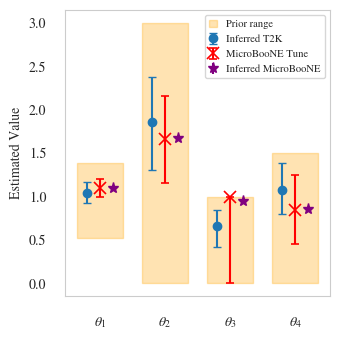

In [48]:
sns.set_style("whitegrid")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "font.size": 10,
    "mathtext.fontset": "stix",
    "text.usetex": False,
})

theta_labels = [r'$\theta_1$', r'$\theta_2$', r'$\theta_3$', r'$\theta_4$']
x = np.arange(len(theta_labels))

# MicroBooNE physics truth values
reference_y = np.array([1.10, 1.66, 1.0, 0.85]) 
# 1sigma uncertainties
reference_yerr_asym = np.array([
    [0.10, 0.5, 1.0, 0.4],   # lower errors MicroBoonE
    [0.10, 0.5, 0.0, 0.4]    # upper errors MicroBoonE
])

# Recovering GENIE units 

theta_max = np.array([theta_or[:,0].max(), theta_or[:,1].max(), theta_or[:,2].max(), theta_or[:,3].max()])
theta_min = np.array([theta_or[:,0].min(), theta_or[:,1].min(), theta_or[:,2].min(), theta_or[:,3].min()])
print(theta_max)
print(theta_min)

# y_normalized_t2k = y_t2k_0

y_normalized_ub = y_ub
yerr_normalized_ub = mean_sigma_1_errors_ub.squeeze()

# Reverse normalization [0,1] to original range
theta_original_t2k = y_t2k_0 * (theta_max - theta_min) + theta_min
print("central value t2k original units: ", y_t2k_0)
print("central value t2k GENIE units: ", theta_original)
print("central value t2k Physical units: ", central)


theta_original_ub = y_normalized_ub * (theta_max - theta_min) + theta_min
print("central value uB original units: ", y_ub)
print("central value uB GENIE units: ", theta_original_ub)
theta_errors_ub = yerr_normalized_ub * (theta_max - theta_min)


# Change to physical units UB

y_physical_ub = np.array([
    MA * (1 + 0.03 * theta_original_ub[0]),        
    1 + (0.5 * theta_original_ub[1]),                
    theta_original_ub[2],                          
    1 - theta_original_ub[3]     
])
print("central value uB physical units: ", y_physical_ub)
# Error propagation UB

yerr_physical_ub = np.array([
    MA * 0.03 * theta_errors_ub[0],                
    0.5 * theta_errors_ub[1],                      
    theta_errors_ub[2],                            
    theta_errors_ub[3]                             
])
print("UB error physical: ", yerr_physical_ub)


# Prior ranges SBI
prior_upper = [1.39, 3, 1, 0] 
prior_lower =  [0.5286, 0, 0, 1.5] 

# Combine into shape (2, N)
prior_errors = np.vstack([prior_lower, prior_upper])

print("central value Physical units: ", y_physical)
print("central value MicroBooNE: ", reference_y)
plt.figure(figsize=(3.5,3.5))
 

for i in range(len(x)):plt.fill_betweenx(y=[prior_lower[i], prior_upper[i]], x1=i - 0.35, x2=i + 0.35, 
                        color='orange', alpha=0.3, label='Prior range' if i == 0 else "" )
    
plt.errorbar(x-0.2, central  , yerr=[lower_err_t2k, upper_err_t2k], fmt='o', capsize=3, label='Inferred T2K')

plt.errorbar(x, reference_y  , yerr=reference_yerr_asym, fmt='x', capsize=3, markersize=8, markeredgewidth=1.2,
                                label='MicroBooNE Tune', color='red')

plt.errorbar(x+0.2, y_physical_ub  , yerr=yerr_physical_ub, fmt='*', capsize=0,
              markersize=8, label='Inferred MicroBooNE', color="purple") 



plt.xticks(x, theta_labels)
plt.ylabel('Estimated Value', fontsize=10)
plt.grid(False)
plt.legend(fontsize=7.7, handlelength=0.75)
plt.tight_layout()
plt.savefig("Posterior_errors_physical_with_truth.pdf", format="pdf", bbox_inches='tight')
plt.show()


[14.9999    3.99997   0.999996  0.999985]
[-1.49996e+01 -1.99997e+00  2.47359e-06 -4.99995e-01]
Removed no burn in


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/2094547600.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  samples = np.array(SBI_sample_array_t2k[0][index])


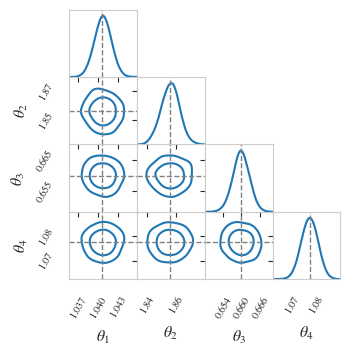

In [50]:
sns.set_style("whitegrid")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "font.size": 10,
    "mathtext.fontset": "stix",
    "text.usetex": False,
    "axes.grid": False,   # <- this disables grids
})

test_number = 1000
weird_index = [0, 5, 10, 15, 20, 25]
theta_1, theta_2, theta_3, theta_4 = central #T2K_0 (central value) in physical units
print(theta_max)
print(theta_min)

for i, index in enumerate(np.ravel(weird_index[0])):
  samples = np.array(SBI_sample_array_t2k[0][index])

  # Original range
  # theta_orig = samples * [15.,  4.,  1.,  1.] #(theta_max - theta_min) + theta_min 
  theta_orig = samples * (theta_max - theta_min) + theta_min  

  # Physical quantities
  MaCCQE_samples = MA + 0.03 * MA * theta_orig[:, 0]
  NormCCMEC_samples = 1 + 0.5 * theta_orig[:, 1]
  XSecShape_CCMEC_samples = theta_orig[:, 2]
  RPA_CCQE_samples = 1 - theta_orig[:, 3]

  # Stack the physical observables
  samples_physical = np.vstack([
      MaCCQE_samples,
      NormCCMEC_samples,
      XSecShape_CCMEC_samples,
      RPA_CCQE_samples
   ]).T


  SBIsingle = MCSamples(samples=np.array(samples_physical),
                            names=[
                                r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'#,
                                # r'\theta_1_t', r'\theta_2_t', r'\theta_3_t', r'\theta_4_t'
                            ],
                            labels=[
                                r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'#,
                                # r'\Delta \theta_1_t', r'\Delta \theta_2_t', r'\Delta \theta_3_t', r'\Delta \theta_4_t'
                            ])

  g = plots.get_subplot_plotter(width_inch=3.5)
  g.settings.scaling_factor = 1
  g.settings.axes_fontsize=10
  g.settings.axis_tick_x_rotation=60
  g.settings.axis_tick_y_rotation=60
  g.settings.scaling_factor = 1
  g.settings.title_limit_labels = False
  g.settings.title_limit_fontsize = 10
  g.settings.axis_marker_lw = 2
  g.settings.tight_layout = False
  g.settings.constrained_layout = False
  g.triangle_plot([SBIsingle],[r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'],
                contour_lws = [1.5,1.5],
                line_args=[{'color':'tab:blue'},{'color':'tab:orange'}],
                  marker_args ={'lw':1},
                  markers={r'\theta_1':theta_1,r'\theta_2':theta_2, r'\theta_3':theta_3, r'\theta_4':theta_4},
                #   param_limits = {r'\theta_1':[-0,1],r'\theta_2':[-0,1],r'\theta_3':[-0,1],r'\theta_4':[0,1]},
                  title_limit=0)
for ax in g.subplots.flatten():
  if ax is not None:
    ax.grid(False)

  plt.savefig('4param_single_image_corner_t2k0.pdf',format='pdf', bbox_inches='tight')

## Testing with NuWro Data

In [51]:
file='nuwro_hist_out.txt'
with open(file, mode="r") as file:
    param_nuw = list(csv.reader(file))
x_nuw = []
numbers_ar_nuw=[]
for i in range(len(param_nuw)):
    numbers_nuw = re.findall(r'[-+]?(?:\d*\.\d+e[+-]?\d+|\d+\.\d+|\d+)', param_nuw[i][0])
    numbers_array_nuw = [float(num) for num in numbers_nuw]
    numbers_ar_nuw.append(numbers_array_nuw)
    if len(numbers_array_nuw) == 58:
        x_nuw.append(numbers_array_nuw)

In [52]:
x_nuw = np.array(x_nuw)/ x_sub.max()
y_nuw_0 = np.array(torch.mean(posterior.sample((1000,), x=x_nuw ), axis=0))
print(y_nuw_0)

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

[0.6682415  0.23362298 0.09434088 0.6158831 ]


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/883504379.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_nuw_0 = np.array(torch.mean(posterior.sample((1000,), x=x_nuw ), axis=0))


In [53]:
print("Inference original units (reverse normalization [0-1]): ", y_nuw_0 * (theta_max - theta_min) + theta_min)
# [ 5.0872, -0.6627,  0.1443,  0.4118]

y_nuwro_or = y_nuw_0 * (theta_max - theta_min) + theta_min

y_physical_nu = np.array([
    MA * (1 + 0.03 * y_nuwro_or[0]),        
    1 + (0.5 * y_nuwro_or[1]),                
    y_nuwro_or[2],                          
    1 - y_nuwro_or[3]     
])

print("Inferred NuWro in physical units: ", y_physical_nu )

Inference original units (reverse normalization [0-1]):  [ 5.047311   -0.5982461   0.09434274  0.42381734]
Inferred NuWro in physical units:  [1.1067926  0.70087695 0.09434274 0.57618266]


In [54]:
array_dump_nuw = make_summary_statistic_array(x_nuw, posterior, 1)

SBI_sample_array_nuw, SBI_logp_array_nuw, SBI_map_array_nuw, SBI_best_fit_arr_nuw, \
SBI_max_like_arr_nuw, SBI_percentile68u_arr_nuw, SBI_percentile68l_arr_nuw, \
SBI_percentile95u_arr_nuw, SBI_percentile95l_arr_nuw = array_dump_nuw

SBI_error_1sigma_nuw = SBI_percentile68u_arr_nuw - SBI_percentile68l_arr_nuw
mean_sigma_1_errors_nuw = SBI_error_1sigma_nuw.mean(axis=1)
print(mean_sigma_1_errors_nuw.squeeze())
print("errors in GENIE units = ", mean_sigma_1_errors_nuw * (theta_max - theta_min))

0


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

[0.00353485 0.00503443 0.01348826 0.00506198]
errors in GENIE units =  [[0.10604384 0.03020629 0.01348818 0.00759287]]


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/2416906237.py:41: UserWarning: `.log_prob()` is deprecated for methods that can only evaluate the log-probability up to a normalizing constant. Use `.potential()` instead.
  logp = posterior.log_prob(samples)
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/2416906237.py:41: UserWarning: The log-probability is unnormalized!
  logp = posterior.log_prob(samples)
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/2416906237.py:43: UserWarning: `.log_prob()` is deprecated for methods that can only evaluate the log-probability up to a normalizing constant. Use `.potential()` instead.
  argmaxlogp = torch.argmax(posterior.log_prob(samples))
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_11653/2416906237.py:43: UserWarning: The log-probability is unnormalized!
  argmaxlogp = torch.argmax(posterior.log_prob(samples))


In [59]:
nu_err_G =  mean_sigma_1_errors_nuw * (theta_max - theta_min)
yerr_physical_nu = np.array([
    MA * 0.03 * nu_err_G[0][0],                
    0.5 * nu_err_G[0][1],                      
    nu_err_G[0][2],                            
    nu_err_G[0][3]                             
])

In [60]:
print("Test samples average: ", SBI_best_fit_arr_nuw.mean(axis=1)[0])
print("central value: ", y_nuw_0)
print("Error physical units: ", yerr_physical_nu)

Test samples average:  [0.6683316  0.23363501 0.09391464 0.6157877 ]
central value:  [0.6682415  0.23362298 0.09434088 0.6158831 ]
Error physical units:  [0.00305801 0.01510314 0.01348818 0.00759287]
